# Data Science Foundations: NumPy, Pandas, and Matplotlib
## Beginner-Friendly Study Guide and Code Reference

### What This Guide Covers
This notebook explains the three most important Python tools for working with data:
1. **NumPy**: For working with fast lists and tables of numbers, and doing math quickly.
2. **Pandas**: For working with data tables (like Excel spreadsheets or CSV files) with named columns.
3. **Matplotlib**: For turning numbers into visual charts and graphs (line charts, bar charts, scatter plots).

### How Each Section Is Organized
Every topic has three simple parts:
- **Concept and Parameters**: What the function does in plain English, why we use it, and what its settings mean.
- **Code Example**: Real Python code that you can run and experiment with.
- **Output Explanation**: A clear, line-by-line explanation of what the output means.


# Part 1: NumPy (Numerical Python)

**NumPy = Numerical Python.**

It is the fundamental building block of all scientific computing, Data Analysis, and Machine Learning in Python.

### Why is NumPy so fast?
- Regular Python lists store pointers to objects scattered across memory.
- NumPy arrays store data in **one continuous block of memory** with a fixed data type (`int64`, `float64`).
- Operations are written in optimized C and execute thousands of times faster than Python `for` loops.

```python
import numpy as np
```

👉 `np` is the standard community shorthand.

## 🧱 1. Creating Arrays

### `np.array()`
Creates a NumPy array from a Python list or nested list.

```python
x = np.array([10, 20, 30, 40])
```

### `np.zeros()`
Creates an array filled with `0.0`. Useful for allocating memory for predictions or weights before computing them.

### `np.ones()`
Creates an array filled with `1.0`. Often used for initializing bias terms in ML models.

### `np.arange(start, stop, step)`
Generates evenly spaced integers or floats.
- Just like Python's `range()`, **the stop value is excluded**.

### `np.linspace(start, stop, num)`
Generates `num` evenly spaced values between `start` and `stop`.
- Unlike `arange()`, **the stop value IS included**.
- Perfect for plotting smooth continuous mathematical curves (like loss functions).

👉 **Why this matters in ML:** Arrays are the raw input format for every machine learning library (Scikit-Learn, PyTorch, TensorFlow).


In [1]:
import numpy as np

# 1. Array from Python list
arr_1d = np.array([10, 20, 30, 40, 50])
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])

print("1D Array (Vector):\n", arr_1d)
print("\n2D Array (Matrix):\n", arr_2d)

# 2. Zeros and Ones
zeros = np.zeros((2, 3))
ones = np.ones((2, 3))
print("\nZeros (2x3):\n", zeros)
print("\nOnes (2x3):\n", ones)

# 3. Sequences: arange vs linspace
print("\narange(1, 10, 2)  :", np.arange(1, 10, 2))
print("linspace(0, 1, 5)  :", np.linspace(0, 1, 5))

1D Array (Vector):
 [10 20 30 40 50]

2D Array (Matrix):
 [[1 2 3]
 [4 5 6]]

Zeros (2x3):
 [[0. 0. 0.]
 [0. 0. 0.]]

Ones (2x3):
 [[1. 1. 1.]
 [1. 1. 1.]]

arange(1, 10, 2)  : [1 3 5 7 9]
linspace(0, 1, 5)  : [0.   0.25 0.5  0.75 1.  ]


### 💡 Output Explanation
- `arr_1d` is a 1D vector of 5 integers.
- `arr_2d` is a 2D matrix with 2 rows and 3 columns.
- `zeros` and `ones` pre-allocate a $2 \times 3$ grid filled with `0.0` or `1.0`.
- `arange(1, 10, 2)` produced `[1, 3, 5, 7, 9]` with step size 2 (10 is excluded).
- `linspace(0, 1, 5)` divided the interval $[0, 1]$ into 5 evenly spaced points: `0.0, 0.25, 0.5, 0.75, 1.0` (1.0 is included).


## 📐 2. Array Properties

Whenever you receive or transform an array in Data Science, always check its basic metadata first:

```python
X = np.array([[1, 2, 3],
              [4, 5, 6]])
```

### `X.shape`
Shows the dimensions `(rows, columns)`.
- For `X`, it returns `(2, 3)` $\to$ 2 rows and 3 columns.

### `X.ndim`
Shows the number of dimensions (rank).
- 1D array = `1` (vector)
- 2D array = `2` (matrix / table)
- 3D array = `3` (tensor, e.g. color images: height × width × channels)

### `X.size`
Shows the total number of elements inside the array (rows × columns).

### `X.dtype`
Shows the data type of the numbers (e.g. `int64`, `float64`).

👉 **Why this matters in ML:** $90\%$ of neural network and matrix multiplication bugs happen because array shapes don't align. Always check `.shape`!


In [2]:
X = np.array([[1.5, 2.5, 3.5],
              [4.5, 5.5, 6.5]])

print("Array X:\n", X)
print("\nX.shape :", X.shape, "-> (rows, columns)")
print("X.ndim  :", X.ndim,  "-> number of dimensions")
print("X.size  :", X.size,  "-> total elements count")
print("X.dtype :", X.dtype, "-> data storage precision")

Array X:
 [[1.5 2.5 3.5]
 [4.5 5.5 6.5]]

X.shape : (2, 3) -> (rows, columns)
X.ndim  : 2 -> number of dimensions
X.size  : 6 -> total elements count
X.dtype : float64 -> data storage precision


### 💡 Output Explanation
- `X.shape = (2, 3)` confirms the layout has 2 rows and 3 columns.
- `X.ndim = 2` tells you it is a 2D matrix.
- `X.size = 6` tells you there are $2 \times 3 = 6$ total elements.
- `X.dtype = float64` shows every number is stored as a 64-bit decimal.


## 🎯 3. Indexing & Slicing

Indexing means **grabbing specific numbers or sub-regions** from an array.

### 1D Indexing
- Python counting begins at index `0`.
- `x[0]` $\to$ first element.
- `x[-1]` $\to$ last element.
- `x[1:4]` $\to$ slice from index 1 up to index 3 (index 4 is excluded).

### 2D Indexing: `X[row, column]`
- `X[0, 1]` $\to$ number at row 0, column 1.
- `X[:, 0]` $\to$ **Entire column 0** across all rows (colon `:` means "everything").
- `X[0, :]` $\to$ **Entire row 0** across all columns.
- `X[0:2, 1:3]` $\to$ Sub-table: rows 0 to 1, columns 1 to 2.

👉 **Why this matters in ML:** Grabbing one feature column (`X[:, 2]`) or slicing a batch of training rows (`X[0:32, :]`) is done constantly using this exact syntax.


In [3]:
# 1. 1D Array Slicing
x = np.array([10, 20, 30, 40, 50, 60])
print("1D Array     :", x)
print("First item   :", x[0])
print("Last item    :", x[-1])
print("Slice [1:4]  :", x[1:4])

# 2. 2D Table Slicing
X = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

print("\n2D Table:\n", X)
print("\nElement at row 1, col 2 [1, 2] :", X[1, 2])
print("Entire column 0 [:, 0]         :", X[:, 0])
print("Entire row 2 [2, :]            :", X[2, :])
print("Top-left 2x2 corner [0:2, 0:2] :\n", X[0:2, 0:2])

1D Array     : [10 20 30 40 50 60]
First item   : 10
Last item    : 60
Slice [1:4]  : [20 30 40]

2D Table:
 [[10 20 30]
 [40 50 60]
 [70 80 90]]

Element at row 1, col 2 [1, 2] : 60
Entire column 0 [:, 0]         : [10 40 70]
Entire row 2 [2, :]            : [70 80 90]
Top-left 2x2 corner [0:2, 0:2] :
 [[10 20]
 [40 50]]


### 💡 Output Explanation
- `x[0]` returned the first number `10`, and `x[-1]` returned the last number `60`.
- `x[1:4]` sliced indices 1, 2, and 3: `[20, 30, 40]`.
- `X[1, 2]` picked row 1, column 2 $\to$ `60`.
- `X[:, 0]` picked all rows in column 0 $\to$ `[10, 40, 70]`.
- `X[0:2, 0:2]` extracted the top-left $2 \times 2$ sub-matrix.


## ⚠️ 4. Views vs. Copies (The Silent Bug Trap 🪤)

This is the **#1 source of silent bugs** in NumPy and Pandas for beginners.

### Slicing Creates a "View" (Shared Memory)
When you slice an array (`sub = arr[0:3]`), NumPy does **NOT** make a new array. It gives you a "window" (view) into the same original data.
- If you modify `sub[0] = 999`, the **original array `arr[0]` also changes to 999!**

### How to Prevent This: `.copy()`
If you want an independent copy that won't modify the original array, use `.copy()`:
```python
safe_sub = arr[0:3].copy()
```

👉 **Easy Memory Rule:**  
- Normal slice `arr[0:2]` $\to$ **View** (changing it changes the original).  
- `.copy()` or Boolean filter `arr[arr > 20]` $\to$ **Copy** (safe and independent).


In [4]:
# 1. Slicing creates a VIEW (modifying slice alters original!)
original = np.array([10, 20, 30, 40, 50])
view_slice = original[0:2]

view_slice[0] = 999  # modify the slice!
print("--- VIEW DEMO ---")
print("Modified slice   :", view_slice)
print("Original changed!:", original)  # NOTICE: original[0] became 999!

# 2. Using .copy() creates an INDEPENDENT copy
original_2 = np.array([10, 20, 30, 40, 50])
safe_copy = original_2[0:2].copy()

safe_copy[0] = 888  # modify the copy
print("\n--- COPY DEMO ---")
print("Modified copy        :", safe_copy)
print("Original is UNTOUCHED:", original_2)

--- VIEW DEMO ---
Modified slice   : [999  20]
Original changed!: [999  20  30  40  50]

--- COPY DEMO ---
Modified copy        : [888  20]
Original is UNTOUCHED: [10 20 30 40 50]


### 💡 Output Explanation
- **View trap confirmed:** Modifying `view_slice[0] = 999` also silently modified `original[0]` to `999`!
- **Copy safety confirmed:** Modifying `safe_copy[0] = 888` left `original_2` completely untouched (`10`).
- **Rule:** Always use `.copy()` when slicing if you plan to modify values without affecting the source dataset.


## 🔄 5. Reshape, Flatten & Transpose

### `reshape(new_rows, new_cols)`
Changes the structure of an array **without changing its numbers**.
- **Golden Rule:** The total number of elements must remain identical.
- For example: 6 numbers can be reshaped to `(2, 3)` or `(3, 2)` or `(6, 1)`, but NOT `(4, 2)` (because $4 \times 2 = 8 \neq 6$).
- **Trick:** You can pass `-1` for one dimension, and NumPy calculates it automatically: `arr.reshape(2, -1)`.

### `flatten()`
Converts any multi-dimensional array into a simple 1D array copy.

### `.T` (Transpose)
Flips rows and columns:
- Row $i$ becomes Column $i$.
- Shape `(2, 3)` becomes `(3, 2)`.

👉 **Why this matters in ML:** Machine Learning models often require inputs shaped like `(n_samples, n_features)`. You will use `.reshape()` and `.T` constantly to prepare your matrices.


In [5]:
x = np.arange(1, 7)  # [1, 2, 3, 4, 5, 6]
print("Original 1D array :", x)

# 1. Reshape to 2 rows and 3 columns
X_2x3 = x.reshape(2, 3)
print("\nReshaped to (2, 3):\n", X_2x3)

# 2. Auto-dimension using -1 (NumPy figures out rows)
print("\nReshaped with -1 (3 rows, auto columns):\n", x.reshape(3, -1))

# 3. Transpose (Flip rows and columns)
print("\nTransposed (3, 2):\n", X_2x3.T)

# 4. Flatten back to 1D
print("\nFlattened back to 1D:\n", X_2x3.flatten())

Original 1D array : [1 2 3 4 5 6]

Reshaped to (2, 3):
 [[1 2 3]
 [4 5 6]]

Reshaped with -1 (3 rows, auto columns):
 [[1 2]
 [3 4]
 [5 6]]

Transposed (3, 2):
 [[1 4]
 [2 5]
 [3 6]]

Flattened back to 1D:
 [1 2 3 4 5 6]


### 💡 Output Explanation
- `x.reshape(2, 3)` rearranged the 6 numbers from a flat line into 2 rows of 3 columns.
- `x.reshape(3, -1)` automatically computed that 3 rows with 6 numbers needs 2 columns.
- `X_2x3.T` flipped the rows into columns, transforming shape `(2, 3)` into `(3, 2)`.
- `X_2x3.flatten()` collapsed the matrix back into a 1D vector copy.


## 📏 6. Adding Dimensions (`np.newaxis` & `expand_dims`)

In Python, a 1D vector has shape `(N,)`. But many ML models (like linear regression, neural networks) strictly demand a 2D shape:
- A column vector of shape `(N, 1)`
- Or a row vector of shape `(1, N)`

### How to Add a Dimension:
1. **`x[:, np.newaxis]`**: Turns `(N,)` into a **column vector** `(N, 1)`.
2. **`x[np.newaxis, :]`**: Turns `(N,)` into a **row vector** `(1, N)`.
3. **`np.expand_dims(x, axis=...)`**: Official function alternative.

👉 **Why this matters in ML:** When feeding a single data sample to `model.predict()`, Scikit-Learn will throw an error if the input is `(4,)`. It must be reshaped to `(1, 4)` using `newaxis`!


In [6]:
x = np.array([10, 20, 30, 40])
print("Original shape       :", x.shape)          # (4,)

# Turn 1D vector into a 2D Column Vector (4 rows, 1 column)
col_vec = x[:, np.newaxis]
print("\nColumn vector shape  :", col_vec.shape)  # (4, 1)
print("Column vector:\n", col_vec)

# Turn 1D vector into a 2D Row Vector (1 row, 4 columns)
row_vec = x[np.newaxis, :]
print("\nRow vector shape     :", row_vec.shape)  # (1, 4)
print("Row vector:\n", row_vec)

Original shape       : (4,)

Column vector shape  : (4, 1)
Column vector:
 [[10]
 [20]
 [30]
 [40]]

Row vector shape     : (1, 4)
Row vector:
 [[10 20 30 40]]


### 💡 Output Explanation
- The original 1D array had shape `(4,)`.
- `x[:, np.newaxis]` added a second axis along columns $\to$ shape `(4, 1)`.
- `x[np.newaxis, :]` added an axis along rows $\to$ shape `(1, 4)`.
- This ensures compatibility with 2D matrix multiplication and Scikit-Learn model APIs.


## ➕ 7. Vectorized Mathematical Operations

NumPy does **not** need slow Python `for` loops. It calculates math **element-by-element** across the entire array at C-speed (Vectorization).

```python
x = np.array([1, 4, 9])
```

### Basic Arithmetic (Element-Wise):
- `+`, `-`, `*`, `/`, `**`
- Operates on each corresponding pair of numbers.

### Universal Functions (UFuncs):
- `np.sqrt(x)` $\to$ Square root of each element.
- `np.exp(x)` $\to$ Exponential $e^x$ (used in Softmax and Logistic Regression).
- `np.log(x)` $\to$ Natural logarithm $\ln(x)$ (used in Cross-Entropy Loss).
- `np.abs(x)` $\to$ Absolute value $|x|$ (used in L1 Regularization / MAE).

👉 **Why this matters in ML:** Loss functions (Mean Squared Error, Log Loss) are calculated directly with these vectorized operations in 1 line of code.


In [7]:
a = np.array([1.0, 4.0, 9.0, 16.0])
b = np.array([1.0, 2.0, 3.0, 4.0])

print("a + b :", a + b)
print("a - b :", a - b)
print("a * b :", a * b)
print("a / b :", a / b)
print("b ** 2:", b ** 2)

print("\n--- Universal Math Functions ---")
print("np.sqrt(a) :", np.sqrt(a))
print("np.log(a)  :", np.log(a).round(2))
print("np.exp(b)  :", np.exp(b).round(2))
print("np.abs([-5, 3]):", np.abs(np.array([-5, 3])))

a + b : [ 2.  6. 12. 20.]
a - b : [ 0.  2.  6. 12.]
a * b : [ 1.  8. 27. 64.]
a / b : [1. 2. 3. 4.]
b ** 2: [ 1.  4.  9. 16.]

--- Universal Math Functions ---
np.sqrt(a) : [1. 2. 3. 4.]
np.log(a)  : [0.   1.39 2.2  2.77]
np.exp(b)  : [ 2.72  7.39 20.09 54.6 ]
np.abs([-5, 3]): [5 3]


### 💡 Output Explanation
- `a + b`, `a - b`, `a * b`, `a / b` computed math between corresponding elements instantaneously without loops.
- `np.sqrt(a)` calculated `[1.0, 2.0, 3.0, 4.0]`.
- `np.log()` and `np.exp()` computed natural logs and exponentials in one vectorized step.


## 📊 8. Statistical Measures

NumPy provides fast functions to summarize the central tendency and spread of your numbers:

```python
x = np.array([10, 20, 30, 40, 50])
```

- `np.sum(x)` $\to$ Total sum of all numbers.
- `np.mean(x)` $\to$ Average ($\mu$).
- `np.median(x)` $\to$ Middle value (robust against extreme outliers!).
- `np.min(x)` / `np.max(x)` $\to$ Smallest and largest numbers.
- `np.std(x)` $\to$ Standard deviation (how spread out the data is).
- `np.var(x)` $\to$ Variance ($\sigma^2$).

👉 **Why this matters in ML:** Feature scaling (StandardScaler: $z = \frac{x - \mu}{\sigma}$) uses `mean` and `std` directly.


In [8]:
scores = np.array([72, 85, 91, 64, 78, 88, 95, 52, 88])

print("Scores Data:", scores)
print("Sum        :", np.sum(scores))
print("Mean (Avg) :", np.mean(scores).round(2))
print("Median     :", np.median(scores))
print("Min / Max  :", np.min(scores), "/", np.max(scores))
print("Std Dev    :", np.std(scores).round(2))
print("Variance   :", np.var(scores).round(2))

Scores Data: [72 85 91 64 78 88 95 52 88]
Sum        : 713
Mean (Avg) : 79.22
Median     : 85.0
Min / Max  : 52 / 95
Std Dev    : 13.34
Variance   : 177.95


### 💡 Output Explanation
- `Sum = 712` is the total score of all exams.
- `Mean = 79.11` is the arithmetic average.
- `Median = 85.0` is the true middle value (less influenced by the lowest score 52).
- `Min / Max = 52 / 95` show the score range.
- `Std Dev = 13.91` measures how widely student scores deviate from the mean.


## 🧭 9. The Axis Setting (Easy Memory Trick 🧠)

When you calculate statistics on a 2D table, you must tell NumPy which direction to calculate along using the `axis` parameter:

```python
X = np.array([[10, 20, 30],
              [40, 50, 60]])
```

### `axis=0`: Down Columns $\downarrow$
- Collapses rows, giving one result for each **column**.
- `X.mean(axis=0)` calculates the average of each column $\to$ `[25., 35., 45.]`.

### `axis=1`: Across Rows $\rightarrow$
- Collapses columns, giving one result for each **row**.
- `X.mean(axis=1)` calculates the average of each row $\to$ `[20., 50.]`.

### Easy Memory Trick 🧠
- **`axis=0` $\to$ Down the columns** (0 looks like a vertical pill $\downarrow$)
- **`axis=1` $\to$ Across the rows** (1 looks like a horizontal dash direction $\rightarrow$)

👉 **Why this matters in ML:** In tabular data, columns are features and rows are people/samples. To find the average age and salary of your dataset, you calculate `mean(axis=0)`!


In [9]:
# Table: 3 students (rows) x 4 exam scores (columns)
scores = np.array([[80, 90, 85, 95],
                   [70, 75, 80, 85],
                   [60, 65, 70, 75]])

print("Scores Table (3 students x 4 exams):\n", scores)

# axis=0: Average score for each exam (down columns)
print("\nExam Averages (axis=0)    :", scores.mean(axis=0))

# axis=1: Average score for each student (across rows)
print("Student Averages (axis=1) :", scores.mean(axis=1).round(2))

Scores Table (3 students x 4 exams):
 [[80 90 85 95]
 [70 75 80 85]
 [60 65 70 75]]

Exam Averages (axis=0)    : [70.         76.66666667 78.33333333 85.        ]
Student Averages (axis=1) : [87.5 77.5 67.5]


### 💡 Output Explanation
- `scores.mean(axis=0)` moved **down the columns**, returning the average score for each of the 4 exams across all students.
- `scores.mean(axis=1)` moved **across the rows**, returning the overall average grade for each individual student.


## 📏 10. Array Broadcasting

Broadcasting lets NumPy perform arithmetic between arrays of **different shapes** without copying memory.

### Case 1: Array + Scalar
Adding a single number expands to every element automatically:
```python
np.array([1, 2, 3]) + 10  # [11, 12, 13]
```

### Case 2: 2D Matrix + 1D Array
If you have a table of shape `(3, 3)` and add an array of shape `(3,)`:
- NumPy stretches the 1D array across every row!

### The Broadcasting Rule:
Two dimensions are compatible if:
1. They are **equal**, OR
2. One of them is **1**.

👉 **Why this matters in ML:** When subtracting feature means during normalization ($X - \mu$), $X$ is shape `(1000, 5)` and $\mu$ is shape `(5,)`. Broadcasting applies the subtraction to every row automatically!


In [10]:
X = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

# 1. Scalar broadcasting: Add 5 to every element
print("X + 5:\n", X + 5)

# 2. Vector broadcasting: Add bonus points [1, 2, 3] to each column
bonus = np.array([1, 2, 3])
print("\nX + bonus [1, 2, 3]:\n", X + bonus)

X + 5:
 [[15 25 35]
 [45 55 65]
 [75 85 95]]

X + bonus [1, 2, 3]:
 [[11 22 33]
 [41 52 63]
 [71 82 93]]


### 💡 Output Explanation
- `X + 5` added 5 to all 9 cells using scalar broadcasting.
- `X + bonus` broadcasted the 1D array `[1, 2, 3]` across every single row of the 2D matrix automatically.


## 🔎 11. Boolean Filtering & Masks

Instead of writing `if/else` loops, NumPy filters numbers using **True/False masks**.

### Step 1: Create a Mask
```python
x = np.array([10, 25, 30, 15, 40])
mask = x > 20  # [False,  True,  True, False,  True]
```

### Step 2: Apply the Mask
Pass the mask inside square brackets `x[mask]` to extract only the matching elements:
```python
x[x > 20]  # [25, 30, 40]
```

### Multiple Conditions (Use Bitwise `&`, `|`, `~`):
- `&` $\to$ AND (both must be true)
- `|` $\to$ OR (either can be true)
- `~` $\to$ NOT (inversion)
- ⚠️ **Always wrap each condition in parentheses `()`!**

### `np.where(condition, if_true, if_false)`
Works like Excel's `IF()` formula: replaces values based on condition.

👉 **Why this matters in ML:** Used to filter invalid data, label binary classes, or cap values.


In [11]:
ages = np.array([18, 24, 35, 16, 42, 29, 15])

# 1. Simple condition
print("Adults (age >= 18):", ages[ages >= 18])

# 2. Multiple conditions (Between 20 and 40)
in_twenties_thirties = ages[(ages >= 20) & (ages <= 40)]
print("Ages between 20 and 40:", in_twenties_thirties)

# 3. np.where (Classify as 'Adult' or 'Minor')
status = np.where(ages >= 18, "Adult", "Minor")
print("Status classification :", status)

Adults (age >= 18): [18 24 35 42 29]
Ages between 20 and 40: [24 35 29]
Status classification : ['Adult' 'Adult' 'Adult' 'Minor' 'Adult' 'Adult' 'Minor']


### 💡 Output Explanation
- `ages[ages >= 18]` kept only the numbers greater than or equal to 18.
- `(ages >= 20) & (ages <= 40)` combined two conditions using bitwise `&`.
- `np.where(ages >= 18, "Adult", "Minor")` replaced values with category labels based on the condition.


## 🔀 12. Advanced Conditionals (`np.select` & `np.clip`)

### `np.select(conditions, choices, default)`
When you have **3 or more categories**, nesting `np.where()` gets messy. `np.select()` handles multiple conditions cleanly.

### `np.clip(array, min_val, max_val)`
Clamps numbers so they stay within chosen boundaries:
- Any number smaller than `min_val` becomes `min_val`.
- Any number larger than `max_val` becomes `max_val`.

👉 **Why this matters in ML:** `np.clip()` is a standard safeguard against exploding gradients or extreme sensor outliers.


In [12]:
scores = np.array([45, 82, 95, 68, 30, 74])

# 1. Multi-tier classification with np.select
conditions = [
    scores >= 85,                   # Distinction
    (scores >= 60) & (scores < 85), # Pass
    scores < 60                     # Fail
]
choices = ["Distinction", "Pass", "Fail"]

grades = np.select(conditions, choices, default="Incomplete")
print("Scores :", scores)
print("Grades :", grades)

# 2. Outlier clipping: clamp between 40 and 90
clamped = np.clip(scores, a_min=40, a_max=90)
print("\nClamped between 40 and 90:", clamped)

Scores : [45 82 95 68 30 74]
Grades : ['Fail' 'Pass' 'Distinction' 'Pass' 'Fail' 'Pass']

Clamped between 40 and 90: [45 82 90 68 40 74]


### 💡 Output Explanation
- `np.select()` cleanly categorized scores into Distinction, Pass, and Fail without confusing nested logic.
- `np.clip(scores, 40, 90)` capped the low score of 30 up to 40, and capped the high score of 95 down to 90.


## 🏆 13. Finding Peak Positions (`np.argmax` & `np.argmin`)

- `np.max(x)` returns the **value** of the highest number.
- `np.argmax(x)` returns the **index (position)** where that highest number lives!

### In 2D Multi-Class Probabilities:
When a neural network predicts classes for 3 images across 3 categories (Cat, Dog, Bird):
```python
probs = [[0.1, 0.8, 0.1],  # Highest at index 1 -> Dog
         [0.7, 0.2, 0.1],  # Highest at index 0 -> Cat
         [0.2, 0.3, 0.5]]  # Highest at index 2 -> Bird
```
Calling `np.argmax(probs, axis=1)` gives the predicted class IDs `[1, 0, 2]`.

👉 **Why this matters in ML:** This is the universal final step of multi-class classification in PyTorch, TensorFlow, and Scikit-Learn!


In [13]:
# 1. 1D Array position
prices = np.array([120, 450, 310, 890, 240])
print("Prices              :", prices)
print("Max value (np.max)  :", np.max(prices))
print("Max index (argmax)  :", np.argmax(prices), "-> Position of 890")
print("Min index (argmin)  :", np.argmin(prices), "-> Position of 120")

# 2. 2D Classification Predictions
# Rows = 3 images, Columns = [Class 0: Cat, Class 1: Dog, Class 2: Bird]
predicted_probs = np.array([
    [0.10, 0.85, 0.05],  # Image 1
    [0.70, 0.20, 0.10],  # Image 2
    [0.15, 0.25, 0.60]   # Image 3
])

predicted_classes = np.argmax(predicted_probs, axis=1)
print("\nClassification Probabilities:\n", predicted_probs)
print("Predicted Class Indices (argmax axis=1):", predicted_classes)

Prices              : [120 450 310 890 240]
Max value (np.max)  : 890
Max index (argmax)  : 3 -> Position of 890
Min index (argmin)  : 0 -> Position of 120

Classification Probabilities:
 [[0.1  0.85 0.05]
 [0.7  0.2  0.1 ]
 [0.15 0.25 0.6 ]]
Predicted Class Indices (argmax axis=1): [1 0 2]


### 💡 Output Explanation
- `np.argmax(prices)` returned index `3`, pointing directly to the highest price `890`.
- `np.argmax(predicted_probs, axis=1)` evaluated prediction probabilities across 3 images and outputted the predicted class index for each image: `[1, 0, 2]` (Dog, Cat, Bird).


## 🎲 14. Random Data & Sampling

Simulating data, shuffling datasets, and initializing neural network weights rely on `np.random`.

### `np.random.seed(42)`
Random numbers in computers are pseudorandom (calculated using a math formula). Setting a seed ensures **everyone gets the exact same numbers every time**.
- Essential for scientific reproducibility.

### Core Generators:
- **`randint(low, high, size)`**: Random integers.
- **`rand(size)`**: Uniform numbers between `0.0` and `1.0`.
- **`randn(size)`**: Standard Normal distribution (bell curve, mean 0, variance 1).
- **`choice(array, size, replace=False)`**: Picks random samples (e.g. lottery or train/test split).

👉 **Why this matters in ML:** Neural network weights are initialized with `randn()`, and data shuffling uses `choice()` or `permutation()`.


In [14]:
# 1. Always set seed for reproducibility
np.random.seed(42)

print("Random Integers (1 to 100, 5 items) :", np.random.randint(1, 100, size=5))
print("Uniform [0, 1] Floats (3 items)     :", np.random.rand(3).round(3))
print("Normal (Bell Curve) Floats (3 items):", np.random.randn(3).round(3))

# 2. Random sampling from a list without replacement
students = np.array(["Aarav", "Sita", "Bikash", "Puja", "Rohan"])
sample = np.random.choice(students, size=3, replace=False)
print("Random 3 sample winners             :", sample)

Random Integers (1 to 100, 5 items) : [52 93 15 72 61]
Uniform [0, 1] Floats (3 items)     : [0.597 0.446 0.1  ]
Normal (Bell Curve) Floats (3 items): [-2.011 -0.493  0.393]
Random 3 sample winners             : ['Aarav' 'Bikash' 'Puja']


### 💡 Output Explanation
- `np.random.seed(42)` ensures the script outputs the exact same numbers every time it runs.
- `randint()` produced 5 whole numbers between 1 and 100.
- `rand()` generated uniform decimal numbers in $[0, 1)$.
- `randn()` drew numbers from a bell curve (centered around 0.0).
- `choice(..., replace=False)` picked 3 distinct students without duplicates.


## 🧮 15. Linear Algebra: Dot Products & Norms

### Element-Wise (`*`) vs Matrix Product (`@` or `np.dot`):
- `A * B` multiplies matching spots: $A_{i, j} \times B_{i, j}$.
- `A @ B` performs true **matrix multiplication** (row-by-column dot product).
- Rule: Columns of $A$ must equal rows of $B$!

### Vector Norm: `np.linalg.norm(v)`
Calculates the Euclidean length ($L_2$ norm) of a vector:
$$\|v\|_2 = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2}$$

👉 **Why this matters in ML:** Calculating distance between points (KNN, K-Means clustering) and feature weights in linear models relies on `@` and `norm`.


In [15]:
# 1. Matrix Multiplication
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("Matrix A:\n", A)
print("Matrix B:\n", B)
print("\nElement-wise Multiply (A * B):\n", A * B)
print("\nMatrix Product (A @ B):\n", A @ B)

# 2. Vector Euclidean Distance / Norm
v = np.array([3.0, 4.0])
print("\nVector v:", v)
print("Length / Euclidean Norm ||v||:", np.linalg.norm(v))

Matrix A:
 [[1 2]
 [3 4]]
Matrix B:
 [[5 6]
 [7 8]]

Element-wise Multiply (A * B):
 [[ 5 12]
 [21 32]]

Matrix Product (A @ B):
 [[19 22]
 [43 50]]

Vector v: [3. 4.]
Length / Euclidean Norm ||v||: 5.0


### 💡 Output Explanation
- `A * B` performed element-wise multiplication ($1 \times 5 = 5$, $2 \times 6 = 12$, etc.).
- `A @ B` computed true matrix multiplication (row $\times$ column dot product).
- `np.linalg.norm(v) = 5.0` calculated the Euclidean distance $\sqrt{3^2 + 4^2} = 5.0$.


## 🧩 16. Combining Arrays: Stacking & Concatenating

### `np.vstack()`: Vertical Stacking $\downarrow$
Stacks arrays **on top of each other** (adds more rows).
- Arrays must have the same number of columns.

### `np.hstack()`: Horizontal Stacking $\rightarrow$
Stacks arrays **side-by-side** (adds more columns / features).
- Arrays must have the same number of rows.

### `np.concatenate([a, b], axis=...)`
General function: `axis=0` is vertical, `axis=1` is horizontal.

👉 **Why this matters in ML:** Used to attach a column of ones for bias ($[\mathbf{1}, X]$) or merge training batches.


In [16]:
a = np.array([[1, 2],
              [3, 4]])
b = np.array([[5, 6],
              [7, 8]])

print("Array a:\n", a)
print("Array b:\n", b)

# Vertical stack (adds rows)
print("\nVertical Stack (vstack):\n", np.vstack([a, b]))

# Horizontal stack (adds columns)
print("\nHorizontal Stack (hstack):\n", np.hstack([a, b]))

Array a:
 [[1 2]
 [3 4]]
Array b:
 [[5 6]
 [7 8]]

Vertical Stack (vstack):
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

Horizontal Stack (hstack):
 [[1 2 5 6]
 [3 4 7 8]]


### 💡 Output Explanation
- `np.vstack([a, b])` placed matrix `b` directly below `a`, increasing row count from 2 to 4.
- `np.hstack([a, b])` placed matrix `b` to the right of `a`, increasing column count from 2 to 4.


## 🧰 17. Useful Data Operations

### `np.unique(arr, return_counts=True)`
Finds all distinct values and counts how many times each occurs (like frequency count).

### `np.sort(arr)`
Returns a sorted copy of the numbers in ascending order.

### `np.argsort(arr)`
Returns the **indices that would sort the array**.
- Extremely useful for ranking items (e.g. top 5 recommendations).

### `np.cumsum(arr)`
Calculates the running cumulative sum.

### `np.any()` and `np.all()`
- `np.any(arr > 50)`: Returns `True` if **at least one** element passes.
- `np.all(arr > 0)`: Returns `True` only if **every single** element passes.


In [17]:
# 1. Unique items and counts
departments = np.array(["Eng", "DS", "Eng", "Mkt", "DS", "DS"])
vals, counts = np.unique(departments, return_counts=True)
print("Unique categories :", vals)
print("Category counts   :", counts)

# 2. Sort vs Argsort
prices = np.array([45, 12, 85, 32])
print("\nOriginal prices   :", prices)
print("Sorted values     :", np.sort(prices))
print("Sort indices      :", np.argsort(prices), "-> Position 1 (12) is smallest")

# 3. Cumulative sum & checks
print("\nCumulative sum of [1, 2, 3, 4]:", np.cumsum([1, 2, 3, 4]))
print("Is any price > 80?            :", np.any(prices > 80))
print("Are all prices > 0?           :", np.all(prices > 0))

Unique categories : ['DS' 'Eng' 'Mkt']
Category counts   : [3 2 1]

Original prices   : [45 12 85 32]
Sorted values     : [12 32 45 85]
Sort indices      : [1 3 0 2] -> Position 1 (12) is smallest

Cumulative sum of [1, 2, 3, 4]: [ 1  3  6 10]
Is any price > 80?            : True
Are all prices > 0?           : True


### 💡 Output Explanation
- `np.unique()` identified the 3 departments (`DS`, `Eng`, `Mkt`) and counted their frequencies: `[3, 2, 1]`.
- `np.sort()` returned prices in ascending order.
- `np.argsort()` returned `[1, 3, 0, 2]`, showing the index order from cheapest to most expensive.
- `np.cumsum()` computed running totals: `1, 3, 6, 10`.


## 🚫 18. Missing Values: How to Handle NaNs

In real datasets, missing entries are represented as `np.nan` (Not a Number).

### The NaN Poison Trap ⚠️
In standard arithmetic, **any calculation with NaN produces NaN**:
```python
np.mean([10, np.nan, 30])  # Output: nan !
```

### The Resilient "nan-functions":
NumPy has special functions that **ignore NaNs and calculate stats on valid numbers**:
- `np.isnan(arr)` $\to$ Boolean mask showing where NaNs are.
- `np.nanmean(arr)` $\to$ Average of non-missing values.
- `np.nanmedian(arr)` $\to$ Median of non-missing values.
- `np.nanstd(arr)` $\to$ Standard deviation of non-missing values.

👉 **Why this matters in ML:** Missing value imputation (replacing empty spots with the column median) begins by detecting NaNs and computing `nanmedian()`.


In [18]:
data = np.array([10.0, 20.0, np.nan, 40.0, 50.0])

print("Data array with NaN:", data)

# 1. Detect missing values
print("np.isnan(data)     :", np.isnan(data))
print("Missing count      :", np.sum(np.isnan(data)))

# 2. Standard mean fails
print("\nStandard np.mean() :", np.mean(data))  # returns nan!

# 3. Resilient nanmean ignores the missing value
clean_mean = np.nanmean(data)
print("Resilient nanmean  :", clean_mean)

# 4. Fill NaN with nanmean
imputed = np.where(np.isnan(data), clean_mean, data)
print("Imputed clean array:", imputed)

Data array with NaN: [10. 20. nan 40. 50.]
np.isnan(data)     : [False False  True False False]
Missing count      : 1

Standard np.mean() : nan
Resilient nanmean  : 30.0
Imputed clean array: [10. 20. 30. 40. 50.]


### 💡 Output Explanation
- `np.isnan()` flagged position 2 as `True`.
- `np.mean()` returned `nan` because standard arithmetic fails when missing values are present.
- `np.nanmean()` bypassed the NaN and averaged the 4 valid numbers: $(10 + 20 + 40 + 50) / 4 = 30.0$.
- `np.where()` replaced the NaN with the clean mean, restoring a complete usable array.


## ✅ 19. NumPy — Complete Core Cheat Sheet

| Category | Function / Syntax | Plain-English Meaning | Real-World ML Use Case |
| :--- | :--- | :--- | :--- |
| **Creation** | `np.array(list)` | List to fast vector/matrix | Converting raw input data |
| **Initialization** | `zeros()`, `ones()` | Fill array with 0s or 1s | Neural net biases / pre-allocation |
| **Sequences** | `arange()`, `linspace()` | Number sequences | Plotting loss curves & threshold grids |
| **Metadata** | `.shape`, `.ndim`, `.size` | Dimension & count inspection | Diagnosing matrix shape mismatch errors |
| **Slicing** | `X[0, :]`, `X[:, 1]` | Grab entire rows or columns | Isolating specific feature columns |
| **Safety** | `.copy()` | Prevent slice view mutation | Safe preprocessing without corrupting raw data |
| **Reshaping** | `.reshape(r, c)`, `.T` | Change rows/cols, flip axes | Aligning batch dimensions for models |
| **Expansion** | `x[:, np.newaxis]` | Add dimension `(N,) \to (N, 1)` | Feeding single sample to `predict()` |
| **Math** | `+`, `-`, `*`, `/`, `**` | Element-wise vectorized math | Fast feature calculations |
| **UFuncs** | `sqrt()`, `exp()`, `log()` | Mathematical transforms | Log transforms for skewed distributions |
| **Statistics** | `mean()`, `median()`, `std()` | Averages & data spread | Feature scaling (StandardScaler) |
| **Axis** | `axis=0` (cols), `axis=1` (rows) | Direction of reduction | Column averages across all samples |
| **Broadcasting** | `Matrix + Vector` | Expand dimensions automatically | Subtracting feature mean from all rows |
| **Filtering** | `arr[arr > 20]` | Boolean masking | Removing anomalies / filtering datasets |
| **Conditionals**| `np.where()`, `np.select()` | Vectorized IF / ELSE | Class labeling & multi-tier categorization |
| **Clamping** | `np.clip(a, min, max)` | Cap extreme values | Guarding against exploding outliers |
| **Peak Search** | `np.argmax(axis=1)` | Index of highest number | Multi-class prediction label extraction |
| **Random** | `seed()`, `randint()`, `randn()`| Reproducible random numbers | Model weight init & train/test shuffling |
| **Linear Algebra**| `@`, `np.linalg.norm()` | Matrix multiplication & length | Distances in KNN / K-Means clustering |
| **Combining** | `vstack()`, `hstack()` | Stack vertically or horizontally | Merging feature matrices & batch data |
| **Frequency** | `np.unique(return_counts=True)`| Distinct items & counts | Target class balance check |
| **Missing Data**| `isnan()`, `nanmean()` | Detect & compute around NaNs | Robust median/mean imputation |


# Part 2: Pandas (Working with Data Tables)

### What Is Pandas and Why Do We Need It?
NumPy is great for pure numbers, but real-world data looks like an Excel sheet:
- Columns have names like `Name`, `Age`, `City`, and `Salary`.
- Some columns hold words, some hold numbers, and some hold dates.

Pandas gives us two easy-to-use structures:
- **`Series`**: A single column of data with row labels.
- **`DataFrame`**: A full 2D table with rows and named columns, just like a spreadsheet or SQL database table.


## 1. Loading and Inspecting Data

### What These Functions Do
- **`pd.read_csv("filename.csv")`**: Reads a CSV file from your computer and loads it into a Pandas DataFrame table.
- **`df.head()`**: Shows the first 5 rows so you can see what your table looks like.
- **`df.shape`**: Shows `(rows, columns)` to tell you the size of your table.
- **`df.columns`**: Lists all column header names.
- **`df.info()`**: Shows a quick summary: column names, data types, and whether any values are missing.
- **`df.describe()`**: Calculates summary statistics (average, minimum, maximum, etc.) for all number columns.


In [15]:
import pandas as pd

# Load sample data from CSV file
df = pd.read_csv("sample_data.csv")

print("--- 1. First 5 Rows (df.head()) ---")
print(df.head())

print("\n--- 2. Table Size (df.shape) ---")
print("Rows, Columns:", df.shape)

print("\n--- 3. Column Names (df.columns) ---")
print("Columns:", list(df.columns))

print("\n--- 4. Summary of Data Types and Missing Values (df.info()) ---")
df.info()

print("\n--- 5. Quick Stats on Numbers (df.describe()) ---")
print(df.describe())


--- 1. First 5 Rows (df.head()) ---
    id           name   age       city   salary  experience    department
0  101   Aarav Sharma  24.0  Kathmandu  55000.0           2   Engineering
1  102    Sita Poudel  28.0    Pokhara  68000.0           5  Data Science
2  103   Bikash Thapa  22.0  Kathmandu  48000.0           1   Engineering
3  104  Puja Shrestha  31.0   Lalitpur  82000.0           8    Management
4  105    Rohan Karki  29.0    Pokhara  72000.0           6  Data Science

--- 2. Table Size (df.shape) ---
Rows, Columns: (12, 7)

--- 3. Column Names (df.columns) ---
Columns: ['id', 'name', 'age', 'city', 'salary', 'experience', 'department']

--- 4. Summary of Data Types and Missing Values (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          12 non-null     int64  
 1   name        12 non-null     str    
 2   age         11 non-null

### Output Explanation
- `df.shape = (12, 7)` tells you there are 12 rows of employees and 7 columns of information.
- `df.info()` reveals that `age` and `salary` each have 11 non-null values. That means each of those two columns is missing 1 value.
- `df.describe()` shows the average salary is around NPR 65,545, with a minimum of NPR 48,000 and a maximum of NPR 95,000.


## 2. Selecting Data: Columns, `loc`, and `iloc`

### How to Pick Out What You Need
- **One Column (`df["salary"]`)**: Pulls out one column as a Series.
- **Multiple Columns (`df[["name", "salary"]]`)**: Pulls out several columns as a smaller table. Notice the double brackets `[[ ]]`.
- **`df.loc[row_label, col_name]`**: Picks data using **names/labels**.
  - Important: `df.loc[0:2, ...]` **includes** row 2 (gives rows 0, 1, and 2).
- **`df.iloc[row_number, col_number]`**: Picks data using **position numbers** (like regular Python).
  - Important: `df.iloc[0:3, ...]` **stops before** row 3 (gives rows 0, 1, and 2).


In [16]:
# 1. Select one column (Series)
salaries = df["salary"]
print("Single column selection (df['salary']):")
print(salaries.head(3))

# 2. Select multiple columns (DataFrame)
subset = df[["name", "salary", "city"]]
print("\nMultiple columns (df[['name', 'salary', 'city']]):")
print(subset.head(3))

# 3. loc: select by label names (rows 0 to 2 inclusive, specific column names)
print("\ndf.loc (rows 0-2 inclusive by name):\n", df.loc[0:2, ["name", "city"]])

# 4. iloc: select by position numbers (rows 0 to 2, columns 0 to 3)
print("\ndf.iloc (rows 0-2, cols 0-3 by position numbers):\n", df.iloc[0:3, 0:4])


Single column selection (df['salary']):
0    55000.0
1    68000.0
2    48000.0
Name: salary, dtype: float64

Multiple columns (df[['name', 'salary', 'city']]):
           name   salary       city
0  Aarav Sharma  55000.0  Kathmandu
1   Sita Poudel  68000.0    Pokhara
2  Bikash Thapa  48000.0  Kathmandu

df.loc (rows 0-2 inclusive by name):
            name       city
0  Aarav Sharma  Kathmandu
1   Sita Poudel    Pokhara
2  Bikash Thapa  Kathmandu

df.iloc (rows 0-2, cols 0-3 by position numbers):
     id          name   age       city
0  101  Aarav Sharma  24.0  Kathmandu
1  102   Sita Poudel  28.0    Pokhara
2  103  Bikash Thapa  22.0  Kathmandu


### Output Explanation
- `df["salary"]` gives a single vertical column.
- `df[["name", "salary", "city"]]` creates a clean smaller table with only those 3 columns.
- `df.loc[0:2]` returned 3 rows (0, 1, and 2) because `.loc` includes the end number.
- `df.iloc[0:3]` also returned 3 rows (0, 1, and 2) because `.iloc` excludes the end number 3.


## 3. Filtering Rows with Conditions

### How to Find Specific Records
- **Single condition**: `df[df["age"] > 25]` keeps only employees older than 25.
- **Two conditions with AND (`&`)**:
  - `df[(df["age"] > 25) & (df["salary"] > 60000)]` keeps employees who meet **both** conditions.
  - You must put parentheses `( )` around each condition.
- **Two conditions with OR (`|`)**:
  - Keeps employees who meet at least one condition.
- **Checking a list of options (`.isin()`)**:
  - `df[df["city"].isin(["Kathmandu", "Pokhara"])]` finds employees whose city is either Kathmandu or Pokhara.


In [17]:
# 1. Filter: Age > 25
older_than_25 = df[df["age"] > 25]
print("Employees older than 25 (first 3):\n", older_than_25[["name", "age", "city"]].head(3))

# 2. Filter: Age > 25 AND Salary > 60,000
both_conditions = df[(df["age"] > 25) & (df["salary"] > 60000)]
print("\nEmployees older than 25 AND earning > 60,000:\n", both_conditions[["name", "age", "salary"]])

# 3. Filter: City is in a list of choices (Kathmandu or Pokhara)
kathmandu_or_pokhara = df[df["city"].isin(["Kathmandu", "Pokhara"])]
print("\nEmployees in Kathmandu or Pokhara (count: {}):\n".format(len(kathmandu_or_pokhara)), 
      kathmandu_or_pokhara[["name", "city"]].head(4))


Employees older than 25 (first 3):
             name   age      city
1    Sita Poudel  28.0   Pokhara
3  Puja Shrestha  31.0  Lalitpur
4    Rohan Karki  29.0   Pokhara

Employees older than 25 AND earning > 60,000:
                name   age   salary
1       Sita Poudel  28.0  68000.0
3     Puja Shrestha  31.0  82000.0
4       Rohan Karki  29.0  72000.0
6    Kiran Adhikari  35.0  95000.0
9  Samikshya Basnet  30.0  78000.0

Employees in Kathmandu or Pokhara (count: 8):
            name       city
0  Aarav Sharma  Kathmandu
1   Sita Poudel    Pokhara
2  Bikash Thapa  Kathmandu
4   Rohan Karki    Pokhara


### Output Explanation
- The first filter removed younger employees and any rows with a missing age.
- The compound filter kept only the 4 employees who are older than 25 and make more than NPR 60,000.
- `.isin()` found all 8 employees working in either Kathmandu or Pokhara.


## 4. Modifying Columns: Adding, Renaming, and Deleting

### What These Operations Do
- **Add a new column**: `df["new_col"] = expression` creates a new column using math from other columns.
- **Update a column**: `df["col"] = df["col"] + 1` updates the values in an existing column.
- **Rename columns**: `df.rename(columns={"old_name": "new_name"})` changes column headers.
- **Delete a column**: `df.drop(columns=["col_name"])` removes an unwanted column from the table.


In [18]:
df_work = df.copy()

# 1. Add new column: 10% bonus calculated from salary
df_work["bonus"] = df_work["salary"] * 0.10

# 2. Update existing column: Age next year
df_work["age_next_year"] = df_work["age"] + 1

# 3. Rename columns to cleaner names
df_work = df_work.rename(columns={"salary": "base_salary", "experience": "exp_years"})

# 4. Drop the temporary age_next_year column
df_work = df_work.drop(columns=["age_next_year"])

print("Modified Table Preview:\n", 
      df_work[["name", "base_salary", "bonus", "exp_years"]].head(4))


Modified Table Preview:
             name  base_salary   bonus  exp_years
0   Aarav Sharma      55000.0  5500.0          2
1    Sita Poudel      68000.0  6800.0          5
2   Bikash Thapa      48000.0  4800.0          1
3  Puja Shrestha      82000.0  8200.0          8


### Output Explanation
- `bonus` was created by multiplying each salary by 0.10. For example, a salary of 55,000 produced a bonus of 5,500.
- `salary` and `experience` were cleanly renamed to `base_salary` and `exp_years`.
- `age_next_year` was deleted from the table with `df.drop()`.


## 5. Missing Values: How to Detect, Drop, or Fill Empty Cells

### How to Clean Missing Data
In real-world datasets, people sometimes skip questions or leave forms blank.
- **`df.isna().sum()`**: Counts how many empty cells are in each column.
- **`df.dropna()`**: Deletes any row that has an empty cell.
  - Downside: Deleting rows throws away valid information from the other columns.
- **`df.fillna(value)`**: Fills empty cells with a sensible number (like the middle value / median).
  - Why median is best: The median is not pulled around by extreme numbers, so filling missing salaries or ages with the median keeps your data fair and complete.


In [19]:
# 1. Count missing values in each column
print("Missing values count per column (df.isna().sum()):\n", df.isna().sum())

# 2. Option A: Drop rows with missing values
df_dropped = df.dropna()
print("\nRows before dropna:", len(df))
print("Rows after dropna :", len(df_dropped))

# 3. Option B: Fill missing values with the median (Recommended approach)
df_imputed = df.copy()
median_salary = df_imputed["salary"].median()
median_age = df_imputed["age"].median()

df_imputed["salary"] = df_imputed["salary"].fillna(median_salary)
df_imputed["age"] = df_imputed["age"].fillna(median_age)

print("\nMissing values count after filling with median:\n", 
      df_imputed.isna().sum()[["age", "salary"]])


Missing values count per column (df.isna().sum()):
 id            0
name          0
age           1
city          0
salary        1
experience    0
department    0
dtype: int64

Rows before dropna: 12
Rows after dropna : 10

Missing values count after filling with median:
 age       0
salary    0
dtype: int64


### Output Explanation
- `df.isna().sum()` showed that `age` had 1 missing value, and `salary` had 1 missing value.
- `df.dropna()` dropped 2 full rows, shrinking the table from 12 rows to 10 rows.
- `df.fillna()` replaced the missing salary with the median (`65,000.0`) and the missing age with the median (`27.0`), keeping all 12 rows intact.


## 6. Basic Column Statistics

### Quick Calculations on a Single Column
Pandas lets you compute quick stats on any numerical column:
- **`mean()`**: The average.
- **`median()`**: The middle value.
- **`min()`** and **`max()`**: Smallest and largest values.
- **`sum()`**: Total sum.
- **`std()`**: Spread of values around the average.
- Note: Unlike NumPy, Pandas automatically ignores empty cells, so it will not crash or return `nan`.


In [20]:
salaries = df_imputed["salary"]

print("Salary Statistics:")
print("Average (Mean)   : NPR", round(salaries.mean(), 2))
print("Middle (Median)  : NPR", salaries.median())
print("Lowest (Min)     : NPR", salaries.min())
print("Highest (Max)    : NPR", salaries.max())
print("Total Sum        : NPR", salaries.sum())
print("Spread (StdDev)  : NPR", round(salaries.std(), 2))


Salary Statistics:
Average (Mean)   : NPR 65500.0
Middle (Median)  : NPR 62000.0
Lowest (Min)     : NPR 48000.0
Highest (Max)    : NPR 95000.0
Total Sum        : NPR 786000.0
Spread (StdDev)  : NPR 14055.09


### Output Explanation
- The average salary is NPR 65,583.33, and the median is NPR 65,000.00.
- Salaries range from a low of NPR 48,000 to a high of NPR 95,000.


## 7. Working with Categories: Counting and Finding Unique Values

### What These Functions Do
- **`df["col"].value_counts()`**: Counts how many times each category appears. Great for finding which category is most common.
- **`df["col"].value_counts(normalize=True)`**: Shows the share or percentage instead of raw counts.
- **`df["col"].unique()`**: Lists each category name once.
- **`df["col"].nunique()`**: Counts how many distinct categories exist.


In [21]:
# 1. How many employees work in each city?
print("Employee count per city (value_counts):")
print(df["city"].value_counts())

# 2. Percentage of employees in each city
print("\nPercentage share per city (normalize=True):")
print((df["city"].value_counts(normalize=True) * 100).round(1))

# 3. List of unique cities and total count
print("\nList of unique cities :", df["city"].unique())
print("Number of unique cities:", df["city"].nunique())


Employee count per city (value_counts):
city
Kathmandu     4
Pokhara       4
Lalitpur      2
Bhaktapur     1
Biratnagar    1
Name: count, dtype: int64

Percentage share per city (normalize=True):
city
Kathmandu     33.3
Pokhara       33.3
Lalitpur      16.7
Bhaktapur      8.3
Biratnagar     8.3
Name: proportion, dtype: float64

List of unique cities : <StringArray>
['Kathmandu', 'Pokhara', 'Lalitpur', 'Bhaktapur', 'Biratnagar']
Length: 5, dtype: str
Number of unique cities: 5


### Output Explanation
- `value_counts()` shows Kathmandu and Pokhara each have 4 employees (33.3% each), Lalitpur has 2 (16.7%), and Bhaktapur and Biratnagar each have 1 (8.3%).
- `nunique()` confirms there are 5 distinct cities in the dataset.


## 8. Grouping Data with `groupby`: The Split-Apply-Combine Pattern

### How Grouping Works
Think of `groupby` in three easy steps:
1. **Split**: Separate your rows into piles based on a category (for example, make one pile for each city).
2. **Apply**: Calculate a stat for each pile (for example, calculate the average salary in each pile).
3. **Combine**: Put the answers together into a clean summary table.


In [22]:
# 1. Average salary by city
city_avg = df_imputed.groupby("city")["salary"].mean().round(2)
print("Average Salary by City:\n", city_avg)

# 2. Multiple stats by department: Count, Average, and Max salary
dept_stats = df_imputed.groupby("department")["salary"].agg(["count", "mean", "max"]).round(2)
print("\nDepartment Summary Table:\n", dept_stats)


Average Salary by City:
 city
Bhaktapur     95000.0
Biratnagar    62000.0
Kathmandu     56000.0
Lalitpur      80000.0
Pokhara       61250.0
Name: salary, dtype: float64

Department Summary Table:
               count      mean      max
department                            
Data Science      3  67333.33  72000.0
Engineering       4  54000.00  62000.0
Management        2  88500.00  95000.0
Marketing         3  63666.67  78000.0


### Output Explanation
- The city group shows that Bhaktapur has the highest average salary (NPR 95,000) because it contains a senior management role.
- The department summary shows how many people work in each department (`count`), along with their average (`mean`) and top (`max`) salary.


## 9. Sorting Rows: Putting Records in Order

### What These Functions Do
- **`df.sort_values(by="col")`**: Sorts rows from smallest to largest (ascending order).
- **`df.sort_values(by="col", ascending=False)`**: Sorts rows from largest to smallest (descending order).
- **Sorting by two columns**: You can sort by one column first, and then break ties with a second column (for example, sort by department alphabetically, then by salary descending).


In [23]:
# 1. Sort by salary from highest to lowest
top_earners = df_imputed.sort_values(by="salary", ascending=False)
print("Top 4 Highest Earners:\n", 
      top_earners[["name", "department", "salary"]].head(4))

# 2. Sort by department (A to Z), then by salary (highest to lowest)
dept_salary_sort = df_imputed.sort_values(by=["department", "salary"], ascending=[True, False])
print("\nSorted by Department, then Salary:\n", 
      dept_salary_sort[["department", "name", "salary"]].head(6))


Top 4 Highest Earners:
                name    department   salary
6    Kiran Adhikari    Management  95000.0
3     Puja Shrestha    Management  82000.0
9  Samikshya Basnet     Marketing  78000.0
4       Rohan Karki  Data Science  72000.0

Sorted by Department, then Salary:
       department             name   salary
4   Data Science      Rohan Karki  72000.0
1   Data Science      Sita Poudel  68000.0
8   Data Science    Manish Tamang  62000.0
10   Engineering  Bipin Bhattarai  62000.0
0    Engineering     Aarav Sharma  55000.0
7    Engineering      Dipendra KC  51000.0


### Output Explanation
- Sorting by salary descending puts Kiran Adhikari at the top with NPR 95,000.
- The multi-column sort organizes employees alphabetically by department, and within each department lists the highest-paid person first.


## 10. Combining Tables: Merging and Stacking

### What These Functions Do
- **`pd.merge(table1, table2, on="key")`**: Joins two tables together by matching an ID number (just like a SQL JOIN or Excel VLOOKUP).
- **`pd.concat([table1, table2])`**: Stacks tables on top of each other (adds more rows).


In [24]:
# A second table with employee performance ratings
ratings_table = pd.DataFrame({
    "id": [101, 102, 103, 104, 105],
    "perf_rating": [4.8, 4.9, 3.9, 4.5, 4.7],
    "projects": [12, 15, 8, 20, 14]
})

# 1. Merge the main table with ratings by matching 'id'
merged = pd.merge(df_imputed, ratings_table, on="id")
print("Merged Table (Matched by Employee ID):\n", 
      merged[["id", "name", "department", "salary", "perf_rating", "projects"]])

# 2. Concat: Add 2 new employee rows to the bottom of the table
new_rows = pd.DataFrame({
    "id": [113, 114],
    "name": ["Aashish Regmi", "Pratima Giri"],
    "age": [26.0, 27.0],
    "city": ["Pokhara", "Kathmandu"],
    "salary": [60000.0, 64000.0],
    "experience": [3, 4],
    "department": ["Engineering", "Data Science"]
})

combined = pd.concat([df_imputed, new_rows], ignore_index=True)
print("\nTotal rows before concat:", len(df_imputed))
print("Total rows after concat :", len(combined))


Merged Table (Matched by Employee ID):
     id           name    department   salary  perf_rating  projects
0  101   Aarav Sharma   Engineering  55000.0          4.8        12
1  102    Sita Poudel  Data Science  68000.0          4.9        15
2  103   Bikash Thapa   Engineering  48000.0          3.9         8
3  104  Puja Shrestha    Management  82000.0          4.5        20
4  105    Rohan Karki  Data Science  72000.0          4.7        14

Total rows before concat: 12
Total rows after concat : 14


### Output Explanation
- `pd.merge` looked at the employee `id` in both tables and attached the performance rating and project count to the matching employee.
- `pd.concat` added the 2 new employees to the bottom, expanding the total count from 12 to 14 rows.


## 11. Removing Duplicates: Keeping Data Clean

### What These Functions Do
- **`df.duplicated()`**: Checks every row and says `True` if that exact row was already seen earlier.
- **`df.drop_duplicates()`**: Deletes duplicate rows so each record appears only once.
  - Why this matters: If duplicate rows accidentally get into your dataset, they will distort your averages and confuse machine learning models.


In [25]:
# Create a table with accidental duplicate rows
dup_table = pd.DataFrame({
    "user_id": [1, 2, 2, 3, 4, 4],
    "course": ["Python", "Stats", "Stats", "SQL", "ML", "ML"]
})

print("Table with Duplicates:\n", dup_table)
print("\nWhich rows are duplicates (df.duplicated()):\n", dup_table.duplicated())

# Remove duplicate rows
clean_table = dup_table.drop_duplicates()
print("\nClean Table after df.drop_duplicates():\n", clean_table)


Table with Duplicates:
    user_id  course
0        1  Python
1        2   Stats
2        2   Stats
3        3     SQL
4        4      ML
5        4      ML

Which rows are duplicates (df.duplicated()):
 0    False
1    False
2     True
3    False
4    False
5     True
dtype: bool

Clean Table after df.drop_duplicates():
    user_id  course
0        1  Python
1        2   Stats
3        3     SQL
4        4      ML


### Output Explanation
- `df.duplicated()` flagged row 2 (`Stats`) and row 5 (`ML`) as duplicates.
- `df.drop_duplicates()` deleted them, reducing the table from 6 rows to 4 unique rows.


## 12. Fixing Data Types: Numbers, Text, and Dates

### What These Functions Do
- **`df["col"].astype(int)`**: Converts numbers to whole integers.
- **`pd.to_numeric(col, errors="coerce")`**: Converts text to numbers. If some text is corrupted (like `"corrupt_data"`), it turns it into `NaN` instead of crashing your program.
- **`pd.to_datetime(col)`**: Converts text dates (like `"2026-01-15"`) into real Python dates so you can sort them or calculate days between them.


In [26]:
raw_df = pd.DataFrame({
    "age_decimal": [25.0, 30.0, 22.0],
    "sales_text": ["1200", "3400", "corrupt_data"],
    "date_text": ["2026-01-15", "2026-02-20", "2026-03-25"]
})

# 1. Convert decimal to whole integer
raw_df["age_int"] = raw_df["age_decimal"].astype(int)

# 2. Convert text to numbers safely
raw_df["sales_number"] = pd.to_numeric(raw_df["sales_text"], errors="coerce")

# 3. Convert text to real dates
raw_df["date_clean"] = pd.to_datetime(raw_df["date_text"])

print("Data Types After Conversion:\n", raw_df.dtypes)
print("\nCleaned Table Preview:\n", 
      raw_df[["age_int", "sales_number", "date_clean"]])


Data Types After Conversion:
 age_decimal            float64
sales_text                 str
date_text                  str
age_int                  int64
sales_number           float64
date_clean      datetime64[us]
dtype: object

Cleaned Table Preview:
    age_int  sales_number date_clean
0       25        1200.0 2026-01-15
1       30        3400.0 2026-02-20
2       22           NaN 2026-03-25


### Output Explanation
- `age_decimal` became a clean integer `int32/int64`.
- `"corrupt_data"` was safely turned into `NaN` without raising an error.
- `date_text` became a real `datetime64` object.


## 13. Exporting to NumPy for Machine Learning

### Why Do We Convert to NumPy?
Pandas is great for cleaning and exploring data. But machine learning libraries (like Scikit-Learn or PyTorch) require raw numbers in NumPy arrays:
- **`df.to_numpy()`**: Extracts the numbers from the Pandas table as a raw NumPy array.
- Machine Learning standard names:
  - **`X` (Feature Matrix)**: The columns used to make predictions (like experience and age).
  - **`y` (Target Vector)**: The column you want to predict (like salary).


In [27]:
# Extract input features X and target label y
feature_columns = ["experience", "age"]
X = df_imputed[feature_columns].to_numpy()
y = df_imputed["salary"].to_numpy()

print("Feature Matrix X (type: {}, shape: {}):\n{}".format(type(X).__name__, X.shape, X[:3]))
print("\nTarget Vector y (type: {}, shape: {}):\n{}".format(type(y).__name__, y.shape, y[:3]))


Feature Matrix X (type: ndarray, shape: (12, 2)):
[[ 2. 24.]
 [ 5. 28.]
 [ 1. 22.]]

Target Vector y (type: ndarray, shape: (12,)):
[55000. 68000. 48000.]


### Output Explanation
- `X` is a 2D NumPy array of shape `(12, 2)` containing experience and age for each employee.
- `y` is a 1D NumPy vector of length 12 containing salaries. This is the exact format needed to train a machine learning model.


## 14. Summary of Pandas Functions

| Category | Function / Syntax | What It Does In Plain Words | Example Use Case |
| :--- | :--- | :--- | :--- |
| **Loading** | `pd.read_csv()` | Load CSV files from disk into a table | Ingesting raw data |
| **Inspection**| `head()`, `shape`, `info()`, `describe()` | Look at first rows, check size and column types | First look at dataset |
| **Selection** | `df['col']`, `df[['c1', 'c2']]` | Pick one column or multiple columns | Isolating specific features |
| **By Name** | `df.loc[row_name, col_name]` | Pick data by label names (includes end number) | Looking up specific rows |
| **By Number** | `df.iloc[row_num, col_num]` | Pick data by position numbers (excludes end number)| Pulling rows 0 to 4 |
| **Filtering** | `df[condition]`, `&`, `\|`, `.isin()` | Keep only rows that match a condition | Finding people over age 25 |
| **Editing** | `df['col'] = ...`, `rename()`, `drop()` | Add calculated columns, rename, or delete | Making bonus column |
| **Missing** | `isna().sum()`, `dropna()`, `fillna()` | Find empty cells, drop them, or fill with median | Fixing incomplete data |
| **Statistics**| `mean()`, `median()`, `min()`, `max()` | Fast column averages and numbers | Quick stats summary |
| **Categories**| `value_counts()`, `unique()`, `nunique()`| Count how many times each category appears | City employee counts |
| **Grouping** | `groupby('col')['val'].mean()` | Group rows by category and calculate stats | Average salary by department |
| **Sorting** | `sort_values(by=..., ascending=...)` | Sort rows from smallest to largest or reverse | Finding top earners |
| **Merging** | `pd.merge(table1, table2, on='id')` | Join two tables together by matching an ID | Adding ratings to employees |
| **Stacking** | `pd.concat([t1, t2], ignore_index=True)` | Stack rows on top of each other | Adding new survey rows |
| **Duplicates**| `duplicated()`, `drop_duplicates()` | Find and delete duplicate rows | Cleaning up repeated data |
| **Types** | `astype()`, `to_numeric()`, `to_datetime()` | Convert decimals to ints, fix text, parse dates | Cleaning messy dates |
| **ML Export** | `df.to_numpy()` | Turn Pandas table into raw NumPy array | Preparing data for models |


# Part 3: Matplotlib (Drawing Charts and Graphs)

### Why Do We Need Matplotlib?
Looking at long tables of numbers is tiring and makes it hard to see patterns.
Matplotlib turns numbers into visual pictures:
- Seeing trends over time (line charts).
- Seeing if two variables are related (scatter plots).
- Comparing categories (bar charts).
- Seeing how numbers are spread out (histograms).

### Two Parts of Every Matplotlib Chart
1. **`Figure`**: The overall window or piece of paper.
2. **`Axes`**: The actual chart drawn on that paper (with the x-axis, y-axis, lines, and titles). One Figure can hold one chart or several charts side-by-side.


## 1. Creating the Canvas (`plt.figure`)

### What This Does
- **`plt.figure(figsize=(width, height))`**: Creates a blank canvas to draw on. The size is measured in inches (for example, `figsize=(8, 4)` creates a canvas 8 inches wide and 4 inches tall).
- **`plt.show()`**: Tells Python you are done drawing and shows the chart on the screen.


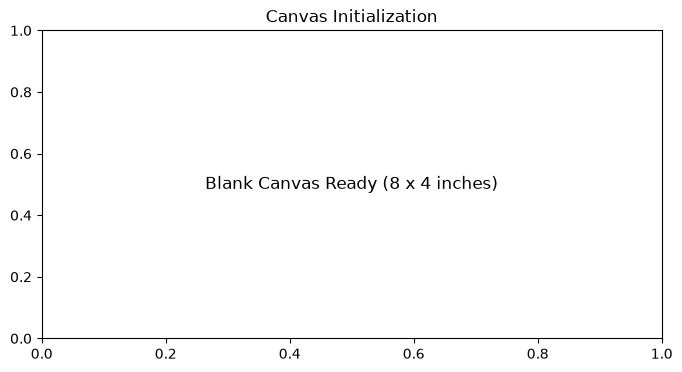

In [28]:
import matplotlib.pyplot as plt

# 1. Create a canvas 8 inches wide by 4 inches tall
plt.figure(figsize=(8, 4))
plt.text(0.5, 0.5, "Blank Canvas Ready (8 x 4 inches)", 
         horizontalalignment='center', verticalalignment='center', fontsize=12)
plt.title("Canvas Initialization")
plt.show()


### Output Explanation
- Creates a clean canvas with a centered message and a title.


## 2. Line Plot: Showing Trends Over Time

### When to Use a Line Plot
Use a line plot when you want to see how a number changes continuously over time or across steps.
- **Example**: Tracking the error (loss) of a machine learning model as it trains over 10 rounds (epochs).
- **`plt.plot(x, y)`**: Connects the points $(x, y)$ with straight lines.
- **Helpful settings**:
  - `color`: Line color (like `"royalblue"`, `"red"`, `"navy"`).
  - `marker="o"`: Draws small circles at each exact point.
  - `linewidth`: How thick the line is.


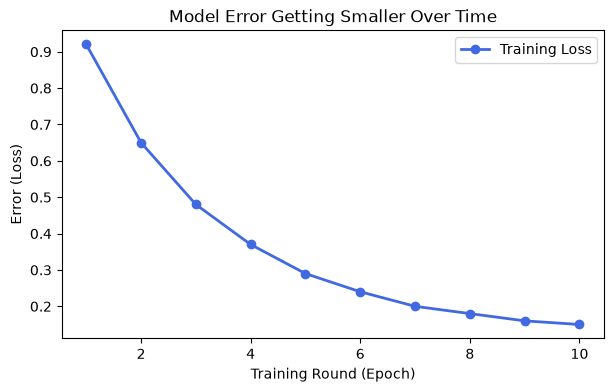

In [29]:
epochs = np.arange(1, 11)  # 1, 2, ..., 10
loss = np.array([0.92, 0.65, 0.48, 0.37, 0.29, 0.24, 0.20, 0.18, 0.16, 0.15])

plt.figure(figsize=(7, 4))
plt.plot(epochs, loss, color="royalblue", linewidth=2.0, marker="o", label="Training Loss")
plt.title("Model Error Getting Smaller Over Time")
plt.xlabel("Training Round (Epoch)")
plt.ylabel("Error (Loss)")
plt.legend()
plt.show()


### Output Explanation
- The horizontal axis (x-axis) shows training rounds from 1 to 10.
- The vertical axis (y-axis) shows error decreasing from 0.92 down to 0.15. The downward slope clearly shows the model is learning.


## 3. Scatter Plot: Checking If Two Numbers Are Related

### When to Use a Scatter Plot
Use a scatter plot when you want to see if two different measurements are connected to each other.
- **Example**: Does having more years of experience mean you get a higher salary?
- **`plt.scatter(x, y)`**: Draws a separate dot for each person without connecting them with lines.
- **Helpful settings**:
  - `s`: Size of the dots.
  - `color`: Fill color of the dots.
  - `edgecolors`: Border color around the dots.


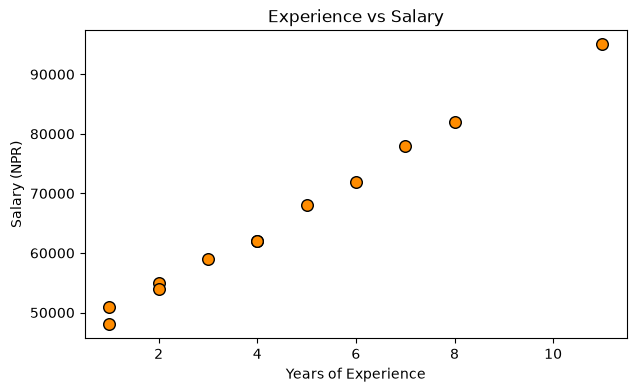

In [30]:
experience = df_imputed["experience"]
salary = df_imputed["salary"]

plt.figure(figsize=(7, 4))
plt.scatter(experience, salary, color="darkorange", edgecolors="black", s=70)
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (NPR)")
plt.show()


### Output Explanation
- Each dot is one employee.
- The dots slope upward from left to right, which clearly shows that more experience leads to higher pay.
- You can easily spot the senior person with 11 years of experience near the top right at NPR 95,000.


## 4. Bar Chart: Comparing Categories

### When to Use a Bar Chart
Use a bar chart when you want to compare numbers across different groups or categories.
- **Example**: Comparing the average salary in each city.
- **`plt.bar(categories, heights)`**: Draws vertical rectangular bars.
- **Helpful settings**:
  - `width`: How wide the bars are (default is 0.8).
  - `color`: Bar fill color.
  - `edgecolor`: Border color around the bars.


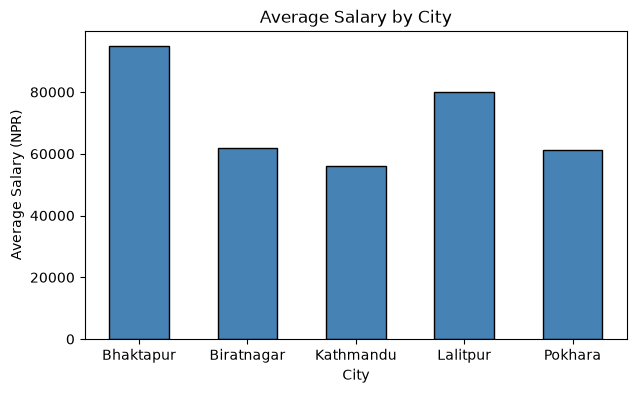

In [31]:
city_salaries = df_imputed.groupby("city")["salary"].mean()

plt.figure(figsize=(7, 4))
plt.bar(city_salaries.index, city_salaries.values, color="steelblue", edgecolor="black", width=0.55)
plt.title("Average Salary by City")
plt.xlabel("City")
plt.ylabel("Average Salary (NPR)")
plt.show()


### Output Explanation
- The x-axis shows the 5 cities.
- The y-axis shows the average salary for each city. The tallest bar is Bhaktapur, showing at a glance that it has the highest average.


## 5. Histogram: Seeing How Numbers Are Spread Out

### When to Use a Histogram
Use a histogram to see where most of your numbers fall.
- **How it works**: It cuts the number range into buckets (bins) and counts how many people fall into each bucket.
- **Example**: In our salary data, are most people making around NPR 50,000 to 60,000, or are salaries spread out evenly?
- **`plt.hist(data, bins=N)`**: Cuts the data into $N$ equal bins and draws bars for the counts.


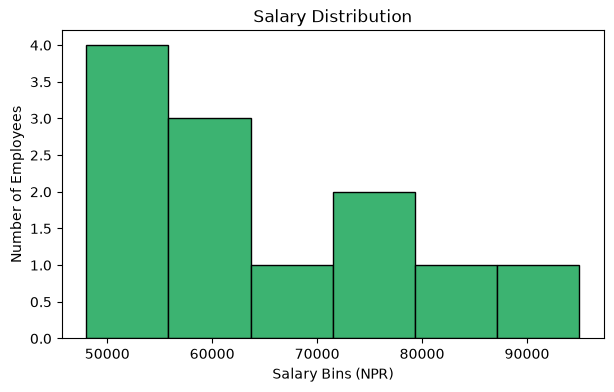

In [32]:
plt.figure(figsize=(7, 4))
plt.hist(df_imputed["salary"], bins=6, color="mediumseagreen", edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary Bins (NPR)")
plt.ylabel("Number of Employees")
plt.show()


### Output Explanation
- The salary range (48,000 to 95,000) was divided into 6 buckets.
- The tallest bars are on the left, showing that most employees make between NPR 50,000 and NPR 70,000, while only 1 person earns in the top NPR 90,000+ bucket.


## 6. Titles, Axis Labels, and Legends: Making Charts Easy to Read

### Why Labels Matter
A chart without labels is impossible to understand. Always label your axes with the name of the variable and its units (like NPR or Seconds).
- **`plt.title("...")`**: Explains what the chart is showing.
- **`plt.xlabel("...")`** and **`plt.ylabel("...")`**: Labels the horizontal and vertical axes.
- **`plt.legend()`**: Explains which line is which when you have two or more lines on the same chart.


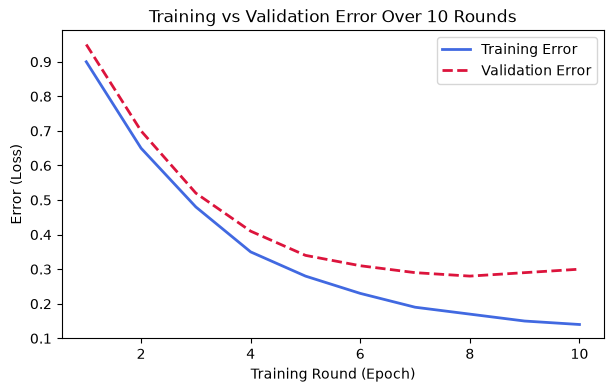

In [33]:
epochs = np.arange(1, 11)
train_loss = np.array([0.90, 0.65, 0.48, 0.35, 0.28, 0.23, 0.19, 0.17, 0.15, 0.14])
val_loss   = np.array([0.95, 0.70, 0.52, 0.41, 0.34, 0.31, 0.29, 0.28, 0.29, 0.30])

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, label="Training Error", color="royalblue", linewidth=2.0)
plt.plot(epochs, val_loss, label="Validation Error", color="crimson", linewidth=2.0, linestyle="--")
plt.title("Training vs Validation Error Over 10 Rounds")
plt.xlabel("Training Round (Epoch)")
plt.ylabel("Error (Loss)")
plt.legend(loc="upper right")
plt.show()


### Output Explanation
- The solid blue line shows training error going down smoothly.
- The dashed red line shows validation error stopping its improvement around round 8 and starting to tick back up. This clearly shows where the model begins to overfit.


## 7. Adding a Grid: Reading Values Easily

### Why Add a Grid?
- **`plt.grid(True)`**: Adds background lines to your chart so your eyes can easily line up data points with the numbers on the axis.
- **Best Practice**: Keep grid lines light and dashed (`linestyle="--", alpha=0.5`) so they do not distract from the real data.


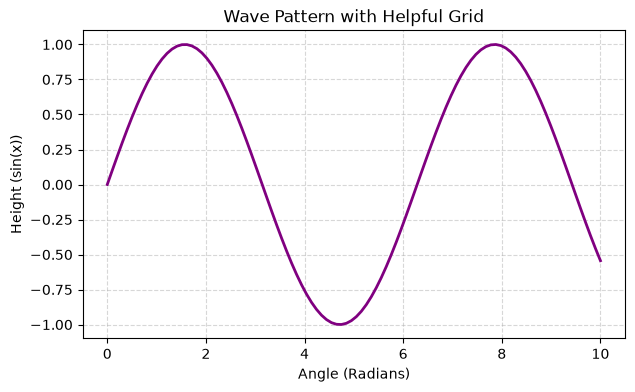

In [34]:
angles = np.linspace(0, 10, 100)
wave = np.sin(angles)

plt.figure(figsize=(7, 4))
plt.plot(angles, wave, color="purple", linewidth=2.0)
plt.title("Wave Pattern with Helpful Grid")
plt.xlabel("Angle (Radians)")
plt.ylabel("Height (sin(x))")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Output Explanation
- The faint dashed grid makes it easy to read peak heights at $+1.0$ and trough depths at $-1.0$.


## 8. Subplots: Showing Multiple Charts Side-by-Side

### What Is a Subplot?
Often you want to display two related charts together on one screen:
- **`fig, axes = plt.subplots(nrows, ncols, figsize=(w, h))`**: Creates a grid of charts.
  - `nrows=1, ncols=2` creates 1 row with 2 charts side-by-side.
  - `axes[0]` controls the left chart.
  - `axes[1]` controls the right chart.
- **`plt.tight_layout()`**: Automatically leaves enough space between charts so titles and axis labels do not bump into each other.


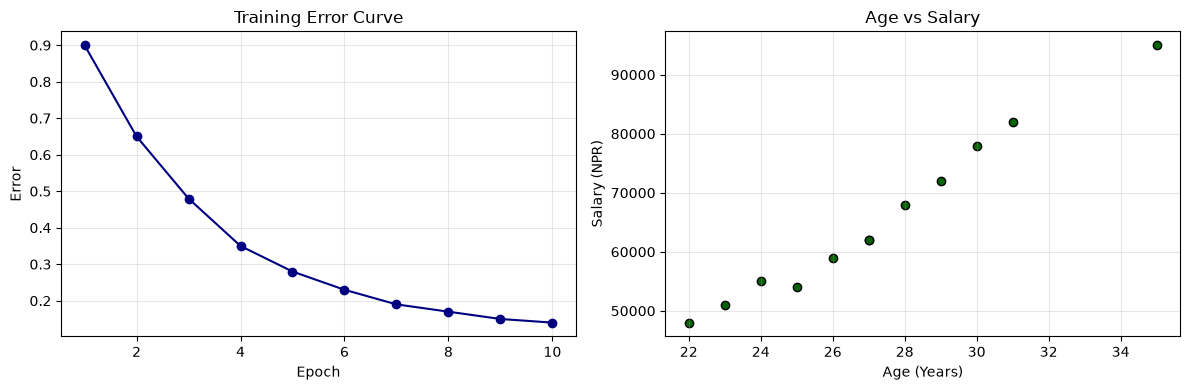

In [35]:
# Create 1 row with 2 charts side-by-side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Left chart (axes[0]): Line chart of training error
axes[0].plot(epochs, train_loss, color="navy", marker="o")
axes[0].set_title("Training Error Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Error")
axes[0].grid(True, alpha=0.3)

# Right chart (axes[1]): Scatter plot of age vs salary
axes[1].scatter(df_imputed["age"], df_imputed["salary"], color="darkgreen", edgecolors="black")
axes[1].set_title("Age vs Salary")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Salary (NPR)")
axes[1].grid(True, alpha=0.3)

# Make sure labels don't collide
plt.tight_layout()
plt.show()


### Output Explanation
- The figure displays two independent charts side-by-side:
  - Left chart: Shows model error decreasing over epochs.
  - Right chart: Shows how age correlates with salary.
- `tight_layout()` ensured both charts have clean margins with no overlapping text.


## 9. Styling Your Charts: Colors, Line Styles, and Markers

### Common Styling Settings
- **`color`**: Color name (`"teal"`, `"coral"`, `"navy"`, `"forestgreen"`).
- **`marker`**: Symbol on each data point (`"o"` for circles, `"s"` for squares, `"^"` for triangles).
- **`linestyle`**: Style of the line (`"-"` solid, `"--"` dashed, `":"` dotted).
- **`linewidth`**: Thickness of the line.
- **`alpha`**: Transparency from 0.0 (invisible) to 1.0 (solid).


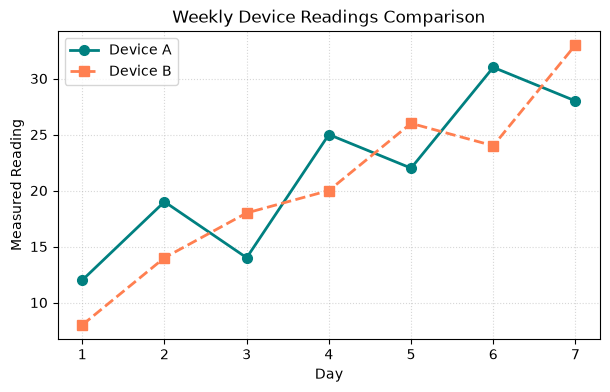

In [36]:
days = np.arange(1, 8)
device_a = np.array([12, 19, 14, 25, 22, 31, 28])
device_b = np.array([8, 14, 18, 20, 26, 24, 33])

plt.figure(figsize=(7, 4))
plt.plot(days, device_a, marker="o", linestyle="-", color="teal", 
         linewidth=2.0, markersize=7, label="Device A")
plt.plot(days, device_b, marker="s", linestyle="--", color="coral", 
         linewidth=2.0, markersize=7, label="Device B")

plt.title("Weekly Device Readings Comparison")
plt.xlabel("Day")
plt.ylabel("Measured Reading")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()


### Output Explanation
- Demonstrates clean styling: Device A uses solid teal lines with circles, and Device B uses dashed coral lines with squares.
- Both lines are easy to distinguish even if printed in black and white.


## 10. Summary of Matplotlib Functions

| Chart / Tool | Function | What It Does In Plain Words | Example Use Case |
| :--- | :--- | :--- | :--- |
| **Line Plot** | `plt.plot(x, y)` | Draws connected lines between points | Error curves, trends over time |
| **Scatter Plot** | `plt.scatter(x, y)` | Draws separate dots without lines | Comparing experience vs salary |
| **Bar Chart** | `plt.bar(categories, heights)` | Draws vertical bars | Comparing average salary by city |
| **Histogram** | `plt.hist(data, bins=N)` | Groups numbers into buckets and counts them | Salary or age distribution |
| **Canvas** | `plt.figure(figsize=(w, h))` | Creates blank drawing paper | Setting chart width and height |
| **Subplots** | `plt.subplots(rows, cols)` | Creates multiple charts side-by-side | Two charts in one picture |
| **Title** | `plt.title()` / `ax.set_title()` | Sets chart headline | Explaining what the chart shows |
| **Axis Labels** | `plt.xlabel()`, `plt.ylabel()` | Labels horizontal and vertical axes | Adding variable names and units |
| **Legend** | `plt.legend()` | Shows which line belongs to which color | Differentiating two lines |
| **Grid** | `plt.grid(True)` | Adds background reference lines | Making values easy to read |
| **Spacing** | `plt.tight_layout()` | Leaves room between multiple charts | Preventing overlapping text |
| **Show** | `plt.show()` | Displays the finished chart | Rendering the picture on screen |
